# 📚 KNN Project: Predict Customer Behaviour 📚

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session
import matplotlib.pyplot as plt 
import seaborn as sns
import scipy
import warnings
warnings.filterwarnings('ignore')

In [2]:
import plotly.express as px
import plotly.io as pio
import itertools

In [3]:
df = pd.read_csv('Customer_Behaviour.csv')

## 1. About Dataset

#### Context
The file has been used in order to apply different machine learning algorithms and to compare different results, taking as an example the Udemy Machine Learning courses files.

Content
The data represents details about 400 clients of a company including the unique ID, the gender, the age of the customer and the salary. Besides this, we have collected information regarding the buying decision - whether the customer decided to buy specific products or not.

target = Purchased

features = User ID, Gender, Age, EstimatedSalary

In [4]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [5]:
df.sample()

,User ID,Gender,Age,EstimatedSalary,Purchased
211,15735878,Male,52,150000,1


In [6]:
df.tail()

,User ID,Gender,Age,EstimatedSalary,Purchased
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0
399,15594041,Female,49,36000,1


In [7]:
df.shape

(400, 5)

In [8]:
df.isna().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [10]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [11]:
df.corr(numeric_only=True)

,User ID,Age,EstimatedSalary,Purchased
User ID,1.000000,-0.000721,0.071097,0.007120
Age,-0.000721,1.000000,0.155238,0.622454
EstimatedSalary,0.071097,0.155238,1.000000,0.362083
Purchased,0.007120,0.622454,0.362083,1.000000


In [12]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [13]:
df.nunique()

User ID            400
Gender               2
Age                 43
EstimatedSalary    117
Purchased            2
dtype: int64

## 2. Preparing Dataset

In [14]:
df.drop('User ID',axis = 1,inplace=True)

In [15]:
df

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0
...,...,...,...,...
395,Female,46,41000,1
396,Male,51,23000,1
397,Female,50,20000,1
398,Male,36,33000,0


##### The Gender column has been left unchanged for now, as it will be encoded using Scikit-learn's OrdinalEncoder during the pipeline preparation step.

## 3. Exploratory Data Analysis (EDA)

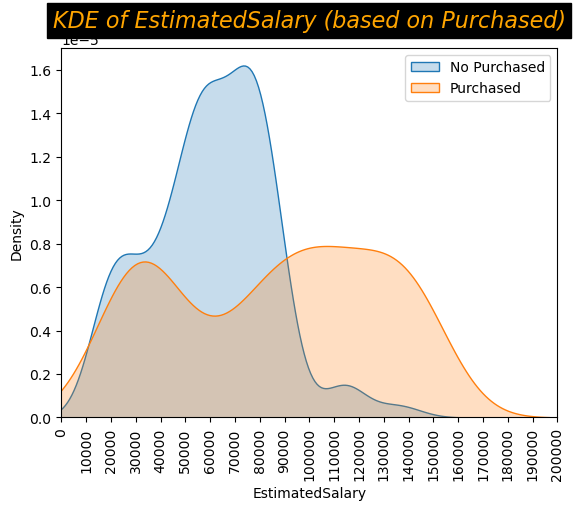

In [16]:
# check distribution of EstimatedSalary (based on Purchased)
font = {'fontsize':16, 'fontstyle':'italic', 'backgroundcolor':'black', 'color':'orange'}
%matplotlib inline
sns.kdeplot(df.loc[df['Purchased'] == 0, 'EstimatedSalary'], label='No Purchased', shade=True)
sns.kdeplot(df.loc[df['Purchased'] == 1, 'EstimatedSalary'], label='Purchased', shade=True)
plt.title('KDE of EstimatedSalary (based on Purchased)', fontdict=font, pad=15)
plt.xticks(np.arange(0,200001,10000), rotation=90)
plt.xlim([0,200001])
plt.legend()
plt.show()

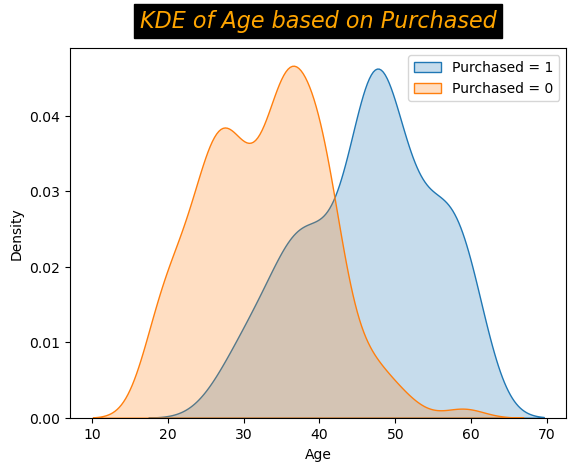

In [17]:
font = {
    'fontsize': 16,
    'fontstyle': 'italic',
    'backgroundcolor': 'black',
    'color': 'orange'
}

sns.kdeplot(
    data=df[df['Purchased'] == 1],
    x='Age',
    fill=True,
    label='Purchased = 1'
)

sns.kdeplot(
    data=df[df['Purchased'] == 0],
    x='Age',
    fill=True,
    label='Purchased = 0'
)

plt.title('KDE of Age based on Purchased', fontdict=font, pad=15)
plt.legend()
plt.show()

* Most people whose income is between 40000 and 90000 don't decide to purchase a product.
* Most people who decide to purchase a product are older than people who don't decide to purchase a product.
* People over the age of 43 are often interested in purchase a product.

## 3.1. Univariate Analysis

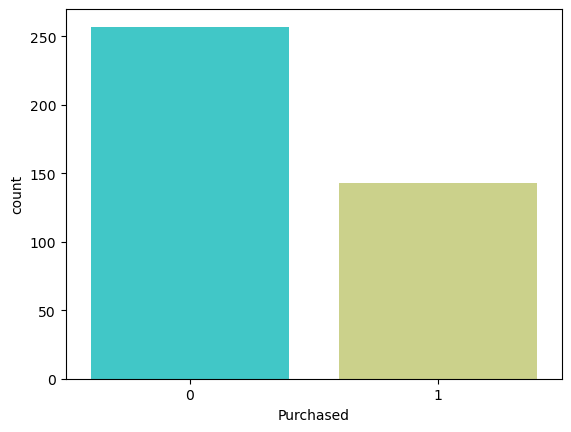

In [18]:
sns.countplot(data=df, x='Purchased', palette='rainbow')
plt.show()

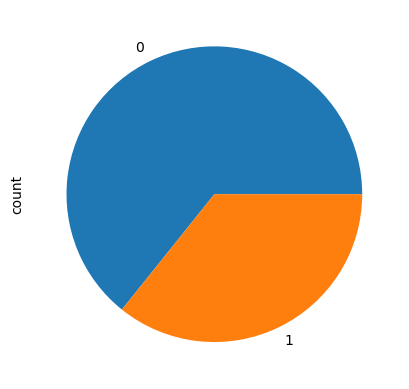

In [19]:
df['Purchased'].value_counts().plot(kind = 'pie')
plt.show()

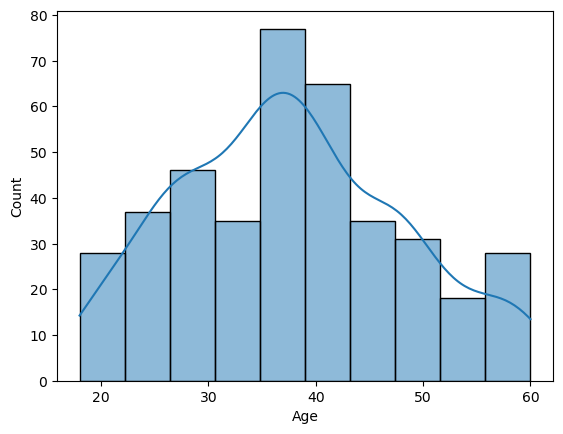

In [20]:
sns.histplot(df['Age'],kde=True)
plt.show()

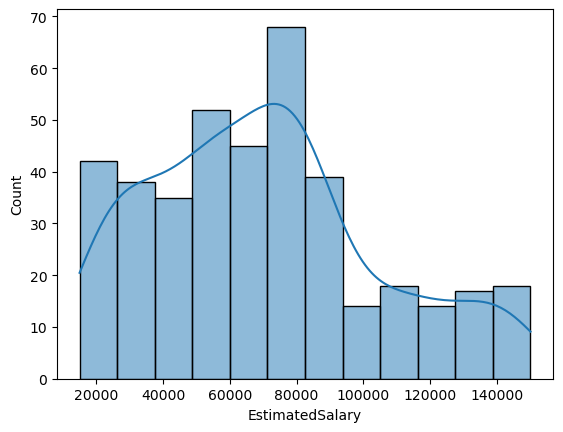

In [21]:
sns.histplot(df['EstimatedSalary'],kde=True)
plt.show()

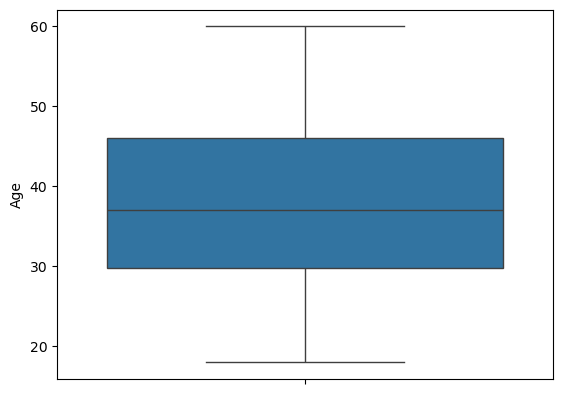

In [22]:
sns.boxplot(df['Age'])
plt.show()

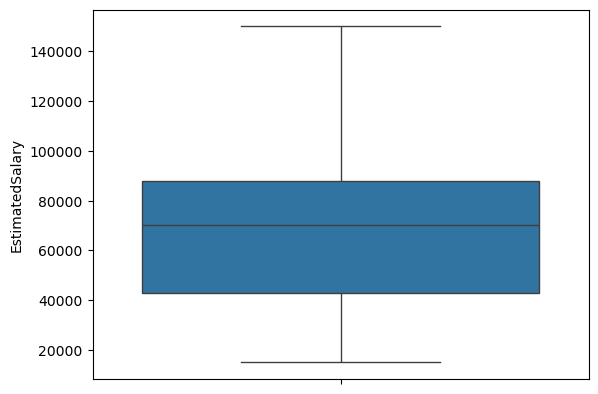

In [23]:
sns.boxplot(df['EstimatedSalary'])
plt.show()

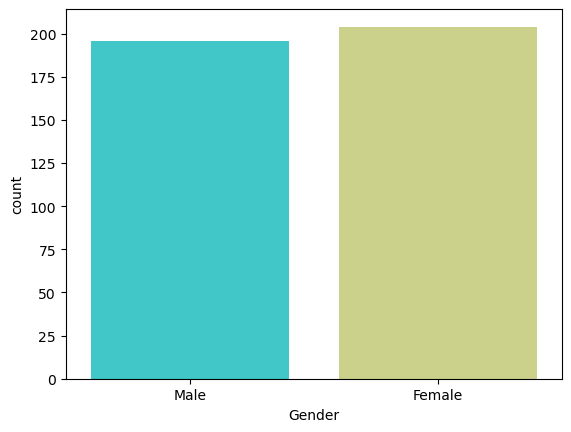

In [24]:
sns.countplot(x = df['Gender'],palette='rainbow')
plt.show()

* According to above barplots and tabel:

* The number of male and female is almost the same
* The number of people who decide to purchased a product is less than the number of people who do not decide to purchased a product.

### 3.2. Bivariate Analysis

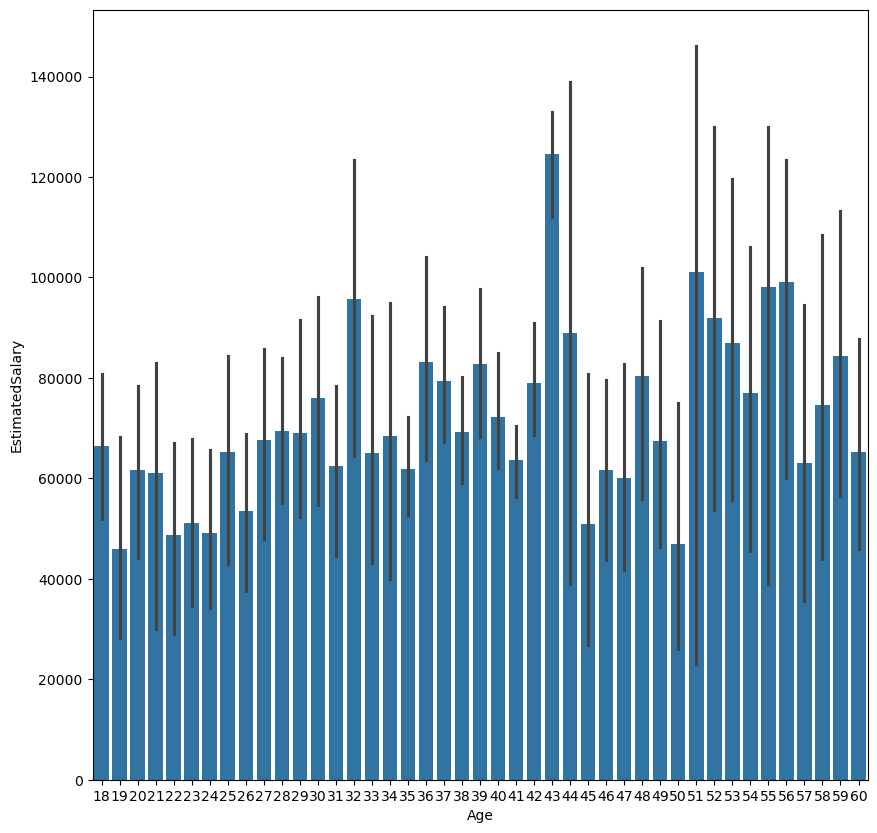

In [27]:
plt.figure(figsize=(10,10))
sns.barplot(x = df['Age'],y = df['EstimatedSalary'])
plt.show()

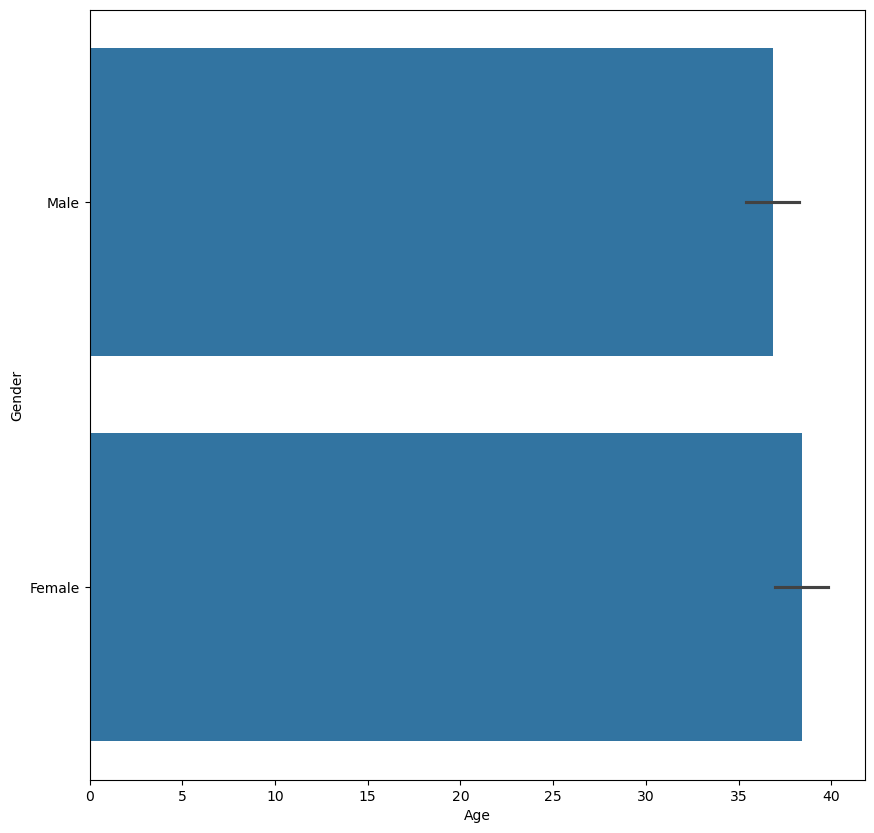

In [29]:
plt.figure(figsize=(10,10))
sns.barplot(x = df['Age'],y = df['Gender'])
plt.show()

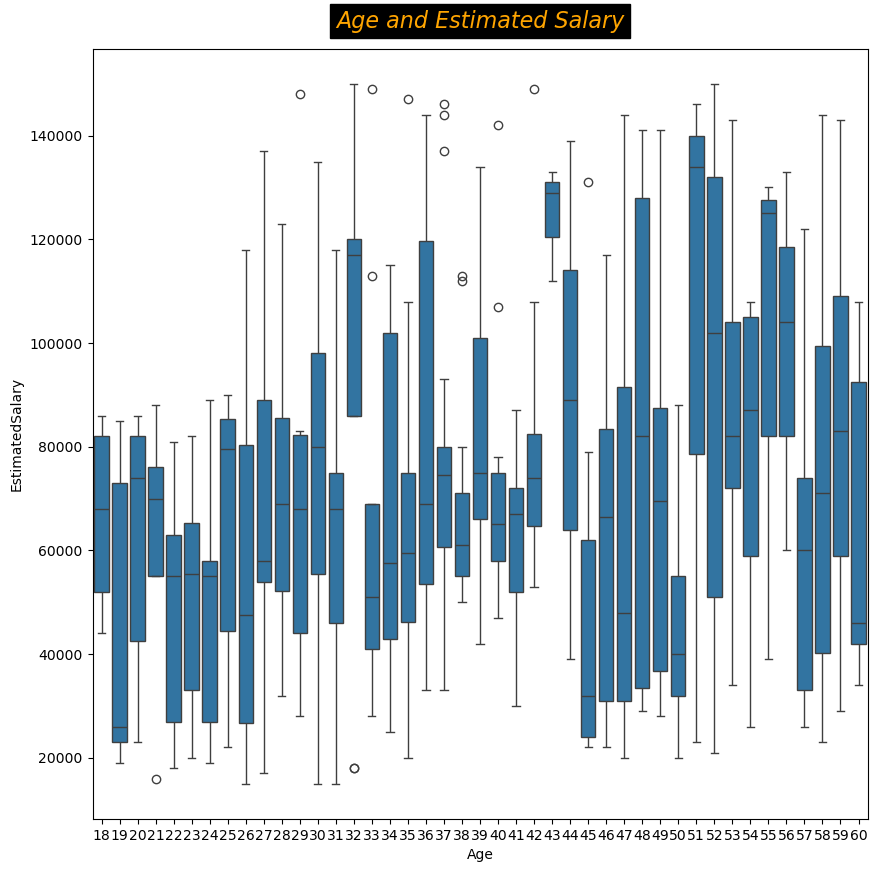

In [35]:
plt.figure(figsize=(10,10))
sns.boxplot(x = df['Age'],y = df['EstimatedSalary'])
plt.title('Age and Estimated Salary', fontdict=font, pad=15)

plt.show()

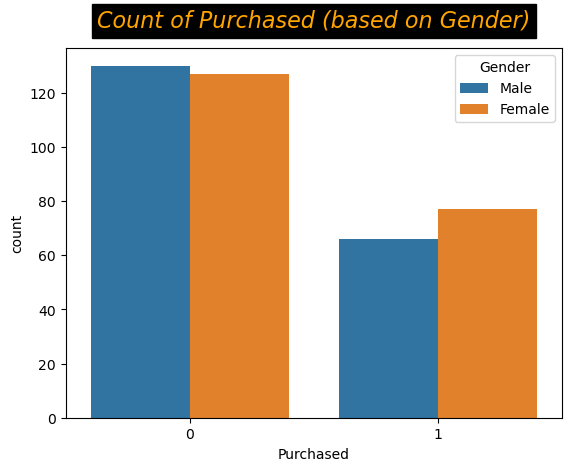

In [34]:
sns.countplot(x = df['Purchased'],hue = df['Gender'])
plt.title('Count of Purchased (based on Gender)', fontdict=font, pad=15)
plt.show()

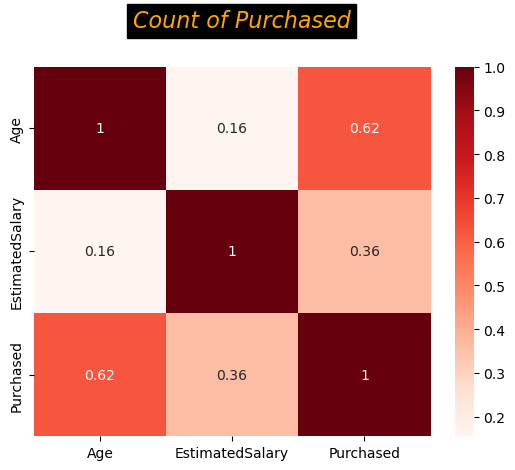

In [40]:
sns.heatmap(df.corr(numeric_only=True), cmap='Reds', annot=True)
plt.suptitle('Count of Purchased', y=1.00, x=0.45, **font)
plt.show()

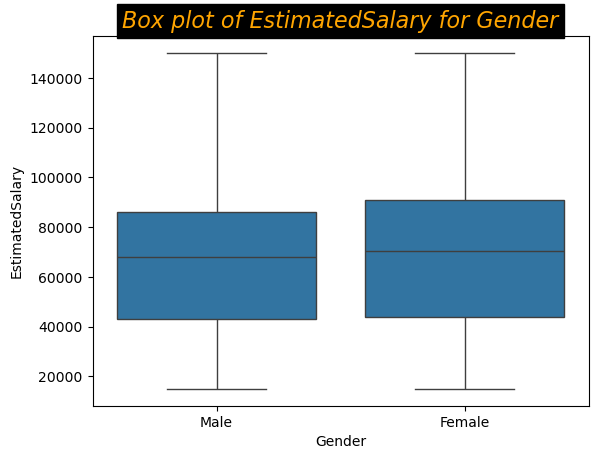

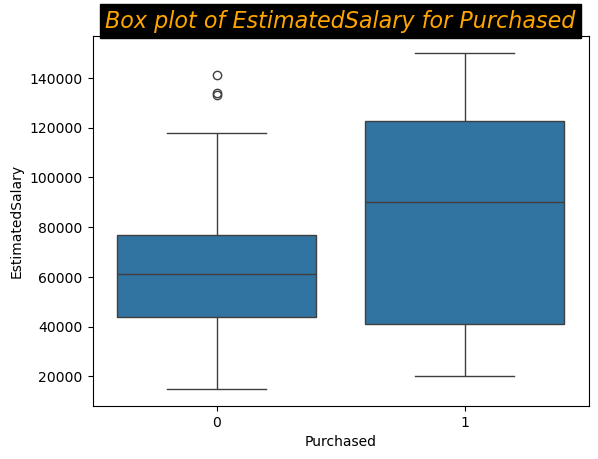

In [41]:
for col in ['Gender','Purchased']:
    sns.boxplot(x = col,y = 'EstimatedSalary',data=df)
    plt.title(f'Box plot of EstimatedSalary for {col}', fontdict=font)
    plt.show()

##### According to above plots:

* Among the people who decide to purchase a product, there are more female than male, but among the people who do not decide to purchase a product, there are more male.
* The highest correlation is between Purchased and Age (0.62).
* The average EstimatedSalary of people who decide to purchase a product is higher than people who do not decide to purchase a product.
* Average EstimatedSalary of male and female do not differ much.

### 3.3. Multivariate Analysis

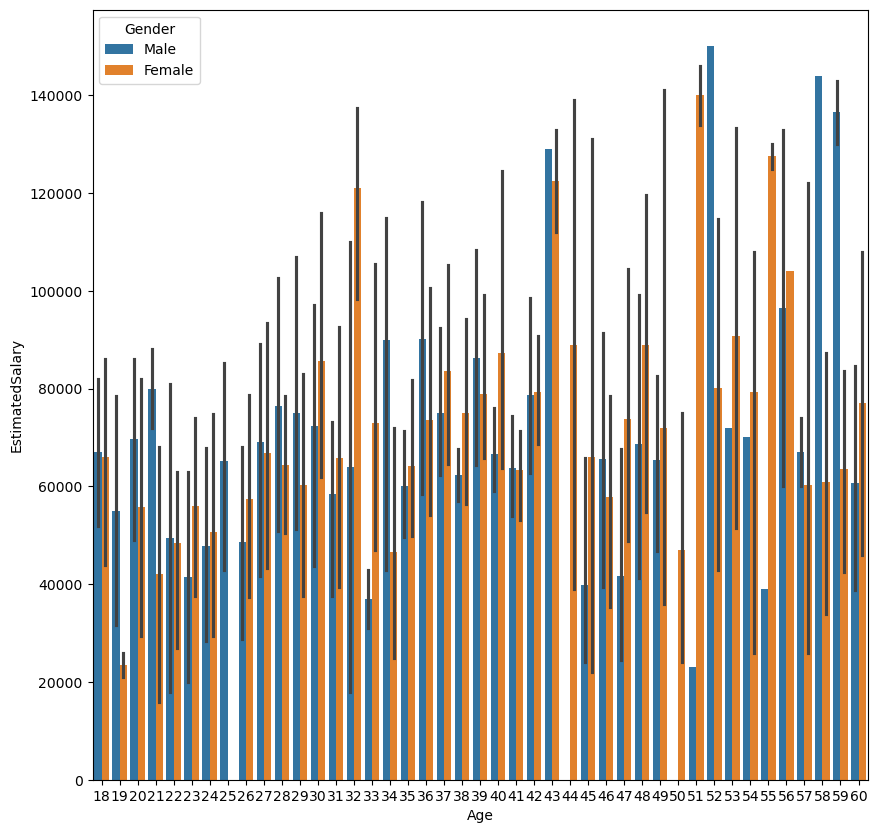

In [42]:
plt.figure(figsize=(10,10))
sns.barplot(x = df['Age'],y = df['EstimatedSalary'],hue = df['Gender'])
plt.show()

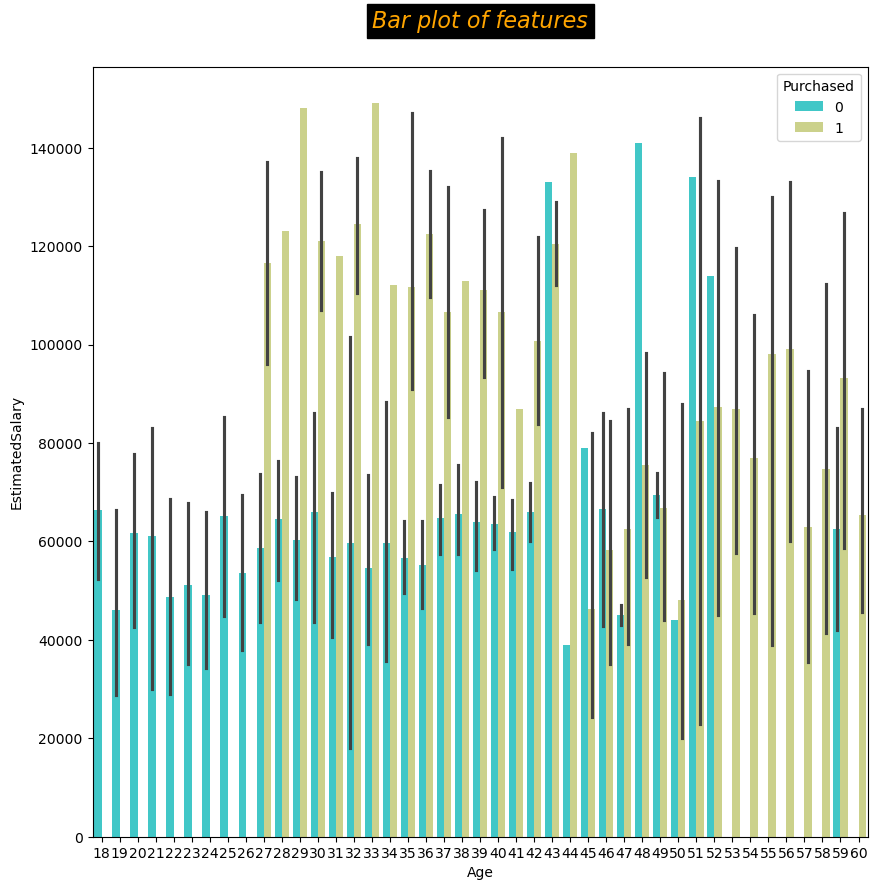

In [47]:
plt.figure(figsize=(10,10))
sns.barplot(x = df['Age'],y = df['EstimatedSalary'],hue = df['Purchased'],palette='rainbow')
plt.title('Bar plot of features', y=1.04, fontdict=font)
plt.show()

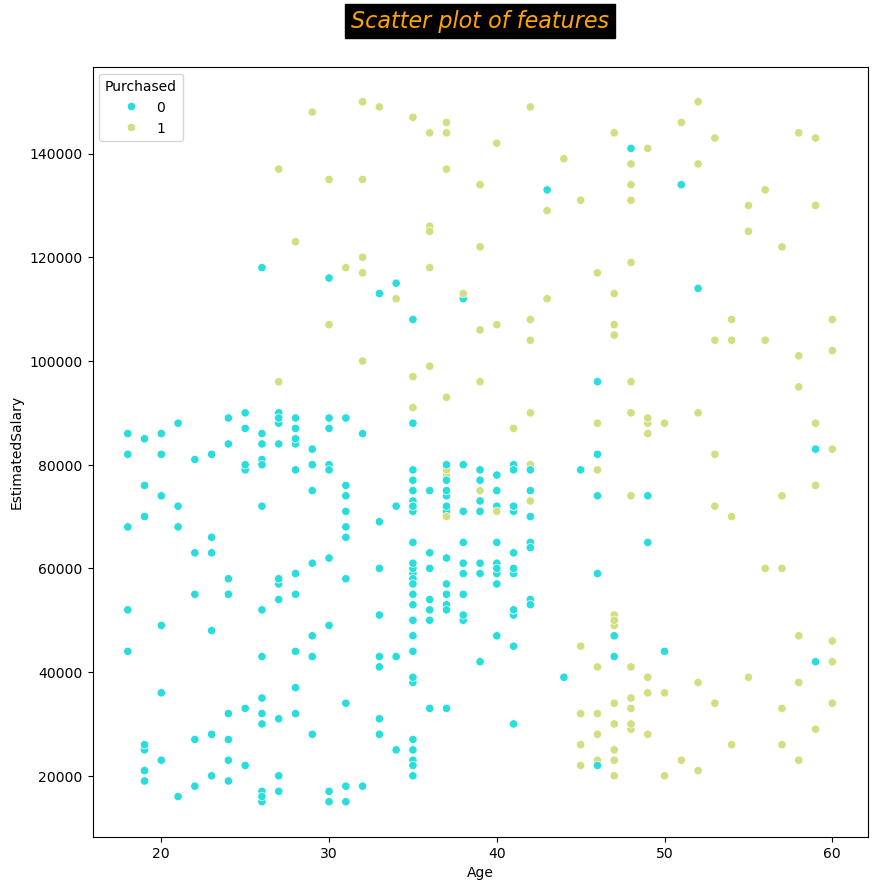

In [46]:
plt.figure(figsize=(10,10))
sns.scatterplot(x = df['Age'],y = df['EstimatedSalary'],hue = df['Purchased'],palette='rainbow')
plt.title('Scatter plot of features', y=1.04, fontdict=font)
plt.show()

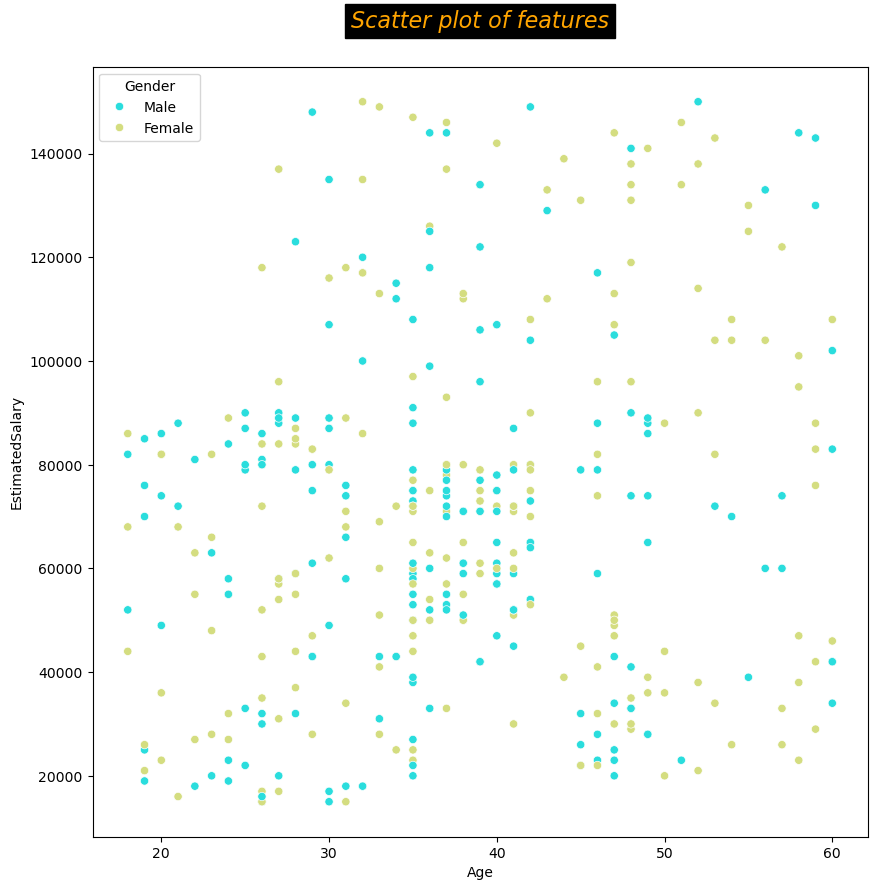

In [48]:
plt.figure(figsize=(10,10))
sns.scatterplot(x = df['Age'],y = df['EstimatedSalary'],hue = df['Gender'],palette='rainbow')
plt.title('Scatter plot of features', y=1.04, fontdict=font)
plt.show()

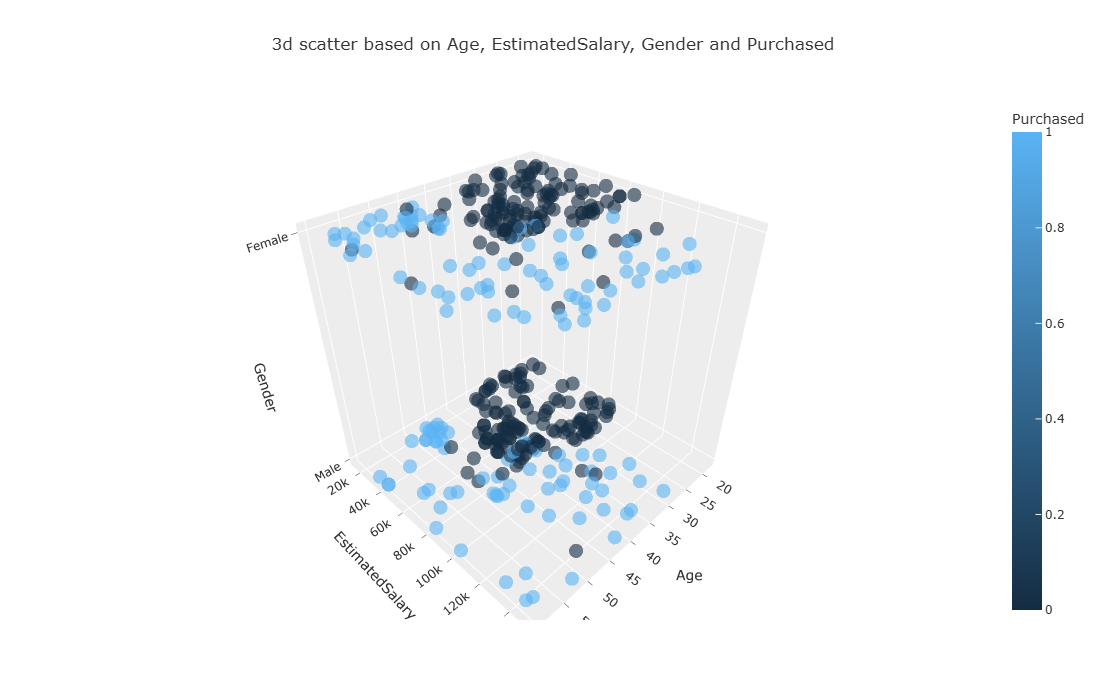

In [49]:
fig = px.scatter_3d(
        data_frame=df,
        x='Age',
        y='EstimatedSalary',
        z='Gender',
        color='Purchased',
        template='ggplot2',
        opacity=0.6,
        height=700,
        title=f'3d scatter based on Age, EstimatedSalary, Gender and Purchased'
)

pio.show(fig)

##### According to above plots:

* People with young age and low EstimatedSalary often do not have a decision to purchase product.
* People with a EstimatedSalary of more than 100000, regardless of their Age, often decide to purchase product.
* People over the age of 45, regardless of their EstimatedSalary, are more likely to pruchase a product.

## 4. Model

In [50]:
df

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0
...,...,...,...,...
395,Female,46,41000,1
396,Male,51,23000,1
397,Female,50,20000,1
398,Male,36,33000,0


In [52]:
df.shape

(400, 4)

In [97]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,classification_report,precision_score,recall_score,f1_score,roc_auc_score,roc_curve

In [58]:
X_train,X_test,y_train,y_test = train_test_split(df.drop('Purchased',axis = 1),df['Purchased'],test_size=0.2,random_state=42)

In [59]:
X_train.shape

(320, 3)

In [60]:
X_test.shape

(80, 3)

In [61]:
y_train.shape


(320,)

In [63]:
y_test.shape

(80,)

In [65]:
tr1 = ColumnTransformer(transformers=[
    ('gender',OneHotEncoder(handle_unknown='ignore',sparse_output=False),['Gender']), 
    ('scaling',StandardScaler(),['EstimatedSalary'])
])

In [66]:
tr1

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('gender', ...), ('scaling', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

In [68]:
pipe1 = Pipeline(steps=[
    ('trf1',tr1), 
    ('model',LogisticRegression(max_iter=1000))
])

In [69]:
pipe1.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('trf1', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('gender', ...), ('scaling', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

In [71]:
y1_pred = pipe1.predict(X_test)

In [72]:
accuracy_score(y_test,y1_pred)

0.75

In [73]:
m1 = LogisticRegression()
m2 = DecisionTreeClassifier()
m3 = KNeighborsClassifier()

In [81]:
m4 = GaussianNB()

In [82]:
pipes = []
for i in [m1,m2,m3,m4]:
    pipe = Pipeline(steps=[
        ('trf1',tr1), 
        ('model',i)
    ])
    pipes.append(pipe)

In [83]:
pipes[1]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('trf1', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('gender', ...), ('scaling', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

In [88]:
for i, pipe in enumerate(pipes, start=1):
    pipe.fit(X_train, y_train)
    print(f"Model {i} Accuracy:", pipe.score(X_test, y_test))

Model 1 Accuracy: 0.75
Model 2 Accuracy: 0.6875
Model 3 Accuracy: 0.6625
Model 4 Accuracy: 0.75


In [89]:
y_pred = []
for pipe in pipes:
    y = pipe.predict(X_test)
    y_pred.append(y)

In [90]:
y_pred[0]

array([0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [93]:
for m, pred in enumerate(y_pred, start=1):
    print(f"Model {m}")
    print(classification_report(y_test, pred))
    print("-" * 50)

Model 1
              precision    recall  f1-score   support

           0       0.74      0.94      0.83        52
           1       0.79      0.39      0.52        28

    accuracy                           0.75        80
   macro avg       0.76      0.67      0.68        80
weighted avg       0.76      0.75      0.72        80

--------------------------------------------------
Model 2
              precision    recall  f1-score   support

           0       0.74      0.81      0.77        52
           1       0.57      0.46      0.51        28

    accuracy                           0.69        80
   macro avg       0.65      0.64      0.64        80
weighted avg       0.68      0.69      0.68        80

--------------------------------------------------
Model 3
              precision    recall  f1-score   support

           0       0.71      0.81      0.76        52
           1       0.52      0.39      0.45        28

    accuracy                           0.66        80
  

In [94]:
y_pred[0] == y_pred[3]

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True])

In [95]:
for i, pipe in enumerate(pipes, start=1):
    y_prob = pipe.predict_proba(X_test)[:, 1]
    print(f"Model {i} ROC-AUC:", roc_auc_score(y_test, y_prob))

Model 1 ROC-AUC: 0.6356456043956044
Model 2 ROC-AUC: 0.6947115384615385
Model 3 ROC-AUC: 0.7475961538461539
Model 4 ROC-AUC: 0.6864697802197802


In [96]:
for i, pipe in enumerate(pipes, start=1):
    print(f"Model {i}: {pipe.named_steps['model']}")

Model 1: LogisticRegression()
Model 2: DecisionTreeClassifier()
Model 3: KNeighborsClassifier()
Model 4: GaussianNB()


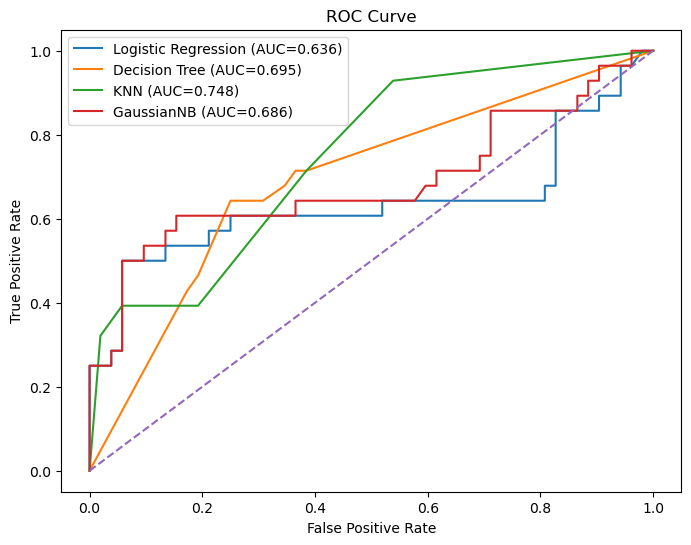

In [98]:
models = [
    "Logistic Regression",
    "Decision Tree",
    "KNN",
    "GaussianNB"
]

plt.figure(figsize=(8, 6))

for name, pipe in zip(models, pipes):
    y_prob = pipe.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## Logistic Regression and GaussianNB achieved the highest accuracy (75%), while KNN achieved the highest ROC-AUC (0.748), indicating stronger overall class discrimination despite lower accuracy at the default threshold.